# Fault detection with PCA, and measuring what it is worth

This is the canonical Tennessee Eastman monitoring experiment. Fit a principal component
model to a record of the fault-free plant, watch two statistics on new data, and raise an
alarm when either leaves its control limit. The two statistics are Hotelling's T-squared,
which measures distance from the training mean inside the subspace the model retained, and
the squared prediction error (written SPE, or Q), which measures how much of an
observation the model could not reconstruct at all. Russell, Chiang and Braatz (2000) and
the textbook by Chiang, Russell and Braatz (2001) are the standard references, and their
Tennessee Eastman results are the ones everyone quotes.

The measurement is the point of this notebook, not the method. Any detector can be made to
look good by reporting only the faults it catches, so every detection rate here is
reported next to the false alarm rate on held-out fault-free data, and one of the two
statistics comes out badly.

The implementation lives in `pcamon.py` beside this notebook. It uses `numpy.linalg` and
the Python standard library and nothing else: no SciPy, no scikit-learn. The F quantile
and the normal quantile that the control limits need are forty lines of incomplete beta
and `statistics.NormalDist`, which is cheaper than a dependency.

*References for this notebook are listed at the bottom.*

In [1]:
import inspect
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tepsim as tep

sys.path.insert(0, str(Path.cwd()))
import pcamon

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.0),
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("tepsim", tep.__version__, "| numpy", np.__version__)

tepsim 0.0.0 | numpy 2.5.2


## The model

`pcamon.fit` standardises each column to zero mean and unit sample variance, forms the
correlation matrix and diagonalises it. Standardisation rather than mere centring is not
optional here: reactor pressure lives near 2705 kPa and a composition is a percentage, so
a covariance model would be a model of the pressure and nothing else.

How many components to keep is a decision, and it is passed as a named rule rather than a
bare integer, because two detectors that retain different numbers of components are
different detectors and a result that does not say which rule produced it cannot be
reproduced. The rule used throughout these notebooks is "enough components to explain 90%
of the variance".

In [2]:
print(inspect.getsource(pcamon.fit))

def fit(X, retain=0.90):
    """Fit a PCA model to a fault-free training matrix.

    ``X`` is samples by variables. Each column is centred on its mean and
    divided by its **sample** standard deviation (the ``n - 1`` one), so the
    matrix that gets diagonalised is the correlation matrix and every variable
    contributes equally regardless of its engineering units. That matters here:
    reactor pressure is near 2705 kPa and a composition is a percentage, and a
    covariance model would be a model of the pressure alone.

    A column that never moved in training has no scale to divide by. It is set
    to exactly zero, its row and column of the correlation matrix are zeroed,
    and its index is reported in ``constant``. The Tennessee Eastman plant has
    such a column in ordinary closed-loop operation: ``XMV(12)``, the agitator
    speed, is held fixed by the base case control scheme.

    ``retain`` is the fraction of total variance the kept components must
    explain. It is 

## The two statistics

T-squared divides each score by its own eigenvalue, so a direction that barely moved
during training weighs a movement far more heavily than one that swung widely. That
division is what makes it a distance rather than a sum of squares, and it is also why it
only sees the retained subspace: dividing by a near-zero eigenvalue would turn rounding
noise into an alarm.

SPE is the part of the observation the model could not explain. The two statistics fail in
different ways and that is the reason to compute both. A fault that moves the plant along
directions the training data already spans inflates T-squared and leaves SPE alone. A
fault that moves the plant somewhere the training data never went shows up in SPE first,
often long before T-squared notices.

In [3]:
print(inspect.getsource(pcamon.statistics))

def statistics(model, X):
    """Both monitoring statistics for every row of ``X``.

    T-squared is the squared Mahalanobis distance from the training mean,
    measured only in the subspace the model retained::

        T^2 = sum_{j < k} (p_j' z)^2 / lambda_j

    Each score is divided by its own eigenvalue, so a direction that barely
    moved during training weighs a movement far more heavily than one that
    swung widely. That division is what makes it a distance and not just a sum
    of squares.

    SPE is what is left over after the retained subspace has explained all it
    can::

        e = z - P_k P_k' z,   SPE = e'e

    The residual is formed by subtracting the reconstruction rather than by
    summing the discarded scores. The two are equal in exact arithmetic, and
    the first is the one that stays right when the loadings are only
    orthonormal to within rounding, because it measures what the model actually
    failed to reconstruct.

    Returns ``(t_squared, spe

## Control limits

The T-squared limit is an F quantile, scaled for the fact that the observation being
tested is independent of the training set. There are two limits in circulation and they
are not interchangeable: the other one, for an observation that was itself part of the
training set, uses a Beta quantile and belongs to a screen of the training data rather
than to a detection experiment.

The SPE limit is the Jackson-Mudholkar approximation. SPE is a weighted sum of squared
normals whose exact distribution has no closed form, so its first three moments are
matched with a power transformation instead, which is why only the first three power sums
of the discarded eigenvalues appear in the expression.

In [4]:
print(inspect.getsource(pcamon.t_squared_limit))
print(inspect.getsource(pcamon.spe_limit))

def t_squared_limit(components, samples, confidence):
    """The upper control limit for T-squared on a new observation::

        T2_alpha = k (n + 1)(n - 1) / (n (n - k)) * F_alpha(k, n - k)

    There are two limits in circulation and they are not interchangeable. This
    is the one for an observation independent of the training set, which is the
    case a fault detection experiment is in: the model is fitted to fault-free
    data and then applied to a different, faulted record. The other, for an
    observation that was itself part of the training set, uses a Beta quantile
    and belongs to a screen of the training data.
    """
    if components == 0:
        return 0.0
    if samples <= components or not 0.0 < confidence < 1.0:
        return float("nan")
    k, n = float(components), float(samples)
    return k * (n + 1.0) * (n - 1.0) / (n * (n - k)) * f_quantile(confidence, k, n - k)

def spe_limit(residual_eigenvalues, confidence):
    """The upper control limit for SPE, b

## Checking the implementation against a reference

Before measuring anything it is worth knowing that the code is right. This repository
already contains a reference implementation of exactly this detector, in Rust, in the
`tepsim-stats` crate, and `book/src/tutorials/a-detector.md` prints a transcript of it on
a specific pair of scenarios. If the NumPy version above is correct it must reproduce that
transcript.

The setup there is a 24-hour fault-free training run from the seed compiled into
`teprob.f`, a second 24-hour fault-free run from a different seed as the held-out record,
and four faults appended to it, with all 53 channels used and the limits at 99%
confidence. The numbers in `expected` below are copied from the book.

In [5]:
HOURS = 24.0
TRAIN_SEED = 4_651_207_995.0
TEST_SEED = 1_234_567_891.0

training = tep.Simulation(tep.Scenario.baseline(hours=HOURS, seed=TRAIN_SEED)).run()
book_model = pcamon.fit(training.to_numpy(), retain=0.90)
book_t2_limit = pcamon.t_squared_limit(book_model["k"], book_model["samples"], 0.99)
book_spe_limit = pcamon.spe_limit(book_model["values"][book_model["k"]:], 0.99)

expected = {"samples": 480, "constant": [52], "components": 33, "explained": 0.9110,
            "t2_limit": 60.386, "spe_limit": 10.481, "far_t2": 0.0208, "far_spe": 0.2042}

free = tep.Simulation(tep.Scenario.baseline(hours=HOURS, seed=TEST_SEED)).run()
free_t2, free_spe = pcamon.statistics(book_model, free.to_numpy())
onset = len(free_t2)

got = {"samples": book_model["samples"], "constant": book_model["constant"].tolist(),
       "components": book_model["k"], "explained": round(book_model["explained"], 4),
       "t2_limit": round(book_t2_limit, 3), "spe_limit": round(book_spe_limit, 3),
       "far_t2": round(float(pcamon.alarms_above(free_t2, book_t2_limit).mean()), 4),
       "far_spe": round(float(pcamon.alarms_above(free_spe, book_spe_limit).mean()), 4)}

print("%-12s %14s %14s   agree" % ("quantity", "book (Rust)", "this notebook"))
for key in expected:
    print("%-12s %14s %14s   %s" % (key, expected[key], got[key], expected[key] == got[key]))

quantity        book (Rust)  this notebook   agree
samples                 480            480   True
constant               [52]           [52]   True
components               33             33   True
explained             0.911          0.911   True
t2_limit             60.386         60.386   True
spe_limit            10.481         10.481   True
far_t2               0.0208         0.0208   True
far_spe              0.2042         0.2042   True


In [6]:
book_detection = {1: (0.994, 3, 0.998, 1), 3: (0.025, None, 0.210, 182),
                  4: (0.502, 29, 0.998, 1), 11: (0.492, 18, 0.731, 8)}

print("        this notebook                    book (Rust)")
print("fault    T2 FDR  dly    Q FDR  dly  |  T2 FDR  dly    Q FDR  dly")
agree = True
for fault, (bt, btd, bq, bqd) in book_detection.items():
    run = tep.Simulation(
        tep.Scenario.baseline(hours=HOURS, seed=TEST_SEED).with_fault(fault)).run()
    t2, spe = pcamon.statistics(book_model, run.to_numpy())
    rt = pcamon.report(pcamon.alarms_above(np.concatenate([free_t2, t2]), book_t2_limit),
                       onset, 3)
    rq = pcamon.report(pcamon.alarms_above(np.concatenate([free_spe, spe]), book_spe_limit),
                       onset, 3)
    mine = (round(rt["fault_detection_rate"], 3), rt["detection_delay"],
            round(rq["fault_detection_rate"], 3), rq["detection_delay"])
    agree &= mine == (bt, btd, bq, bqd)
    print("IDV(%2d)  %6.3f %4s   %6.3f %4s  |  %6.3f %4s   %6.3f %4s"
          % (fault, mine[0], mine[1], mine[2], mine[3], bt, btd, bq, bqd))
print()
print("every printed digit agrees with the Rust reference:", bool(agree))

        this notebook                    book (Rust)
fault    T2 FDR  dly    Q FDR  dly  |  T2 FDR  dly    Q FDR  dly


IDV( 1)   0.994    3    0.998    1  |   0.994    3    0.998    1


IDV( 3)   0.025 None    0.210  182  |   0.025 None    0.210  182


IDV( 4)   0.502   29    0.998    1  |   0.502   29    0.998    1


IDV(11)   0.492   18    0.731    8  |   0.492   18    0.731    8

every printed digit agrees with the Rust reference: True


Every digit matches, which is worth more than it looks. The Rust implementation
diagonalises with a hand-written cyclic Jacobi sweep and this one calls LAPACK through
`numpy.linalg.eigh`; they agree to three decimals on the limits and exactly on every
detection rate and delay. Whatever is measured below is a property of the plant and the
method, not of the linear algebra.

## The experiment the literature runs

The published Tennessee Eastman datasets, `d00` through `d21`, have a specific shape, and
matching it makes results comparable. A test record is 48 simulated hours at a
three-minute sampling interval, so 960 samples, with the fault introduced 8 hours in, at
sample 160. That gives 160 fault-free samples to measure the false alarm rate on and 800
faulted samples to measure the detection rate on. The training record is fault-free
throughout.

Two details of the setup below are deliberate:

The 52 columns used are `XMEAS(1..41)` followed by `XMV(1..11)`, which is exactly the
layout of the published files. `XMV(12)`, the agitator speed, is not in them because the
base case control scheme holds it constant, and a column that never moves has no scale to
standardise by.

`driver_forces_idv12` is left off, which is this port's default. The original closed-loop
driver contains a line that switches `IDV(12)` on eight hours into every run whatever the
caller asked for, so a run nominally labelled `IDV(4)` would really be `IDV(4)` and
`IDV(12)` together, and both act on cooling water. This repository established (see
`book/src/deltas.md`, delta D-011) that the published datasets were generated with that
line replaced rather than kept, so leaving it off is what matches the data.

In [7]:
PUBLISHED_COLUMNS = np.r_[0:41, 41:52]     # XMEAS(1..41), XMV(1..11)
ONSET = 160
CONFIDENCE = 0.99
CONSECUTIVE = 3


def fault_free(hours, seed):
    return tep.Scenario.baseline(hours=hours, seed=seed)


def arriving_at(fault, hour, base):
    "`base`, with IDV(fault) switching on at `hour`."
    return tep.Scenario.from_text(
        base.to_text().replace("events=", "events=%g:start:%d" % (hour, fault)))


def observed(run):
    "A run as the 52 columns the published files carry."
    return run.to_numpy()[:, PUBLISHED_COLUMNS]


training = tep.Simulation(fault_free(25.0, TRAIN_SEED)).run()
model = pcamon.fit(observed(training), retain=0.90)
t2_limit = pcamon.t_squared_limit(model["k"], model["samples"], CONFIDENCE)
spe_limit = pcamon.spe_limit(model["values"][model["k"]:], CONFIDENCE)

print("training record   %d samples x %d variables (%.0f hours)"
      % (model["samples"], model["variables"], training.hours[-1]))
print("numerical rank    %d" % model["rank"])
print("components kept   %d, explaining %.4f of the variance"
      % (model["k"], model["explained"]))
print("T-squared limit   %.3f   at %.0f%% confidence" % (t2_limit, 100 * CONFIDENCE))
print("SPE limit         %.3f" % spe_limit)

training record   500 samples x 52 variables (25 hours)
numerical rank    52
components kept   33, explaining 0.9101 of the variance
T-squared limit   60.141   at 99% confidence
SPE limit         10.593


The spectrum below is why so many components are needed. The plant has 52 recorded
variables and they are correlated, but not nearly as strongly as one might hope: there is
no small handful of dominant directions, and the largest eigenvalue accounts for only
about a ninth of the total. Reaching 90% of the variance takes two thirds of the
available components. A monitoring scheme on this plant is therefore working in a fairly
high-dimensional retained subspace, and the residual subspace it compares against is not
small either.

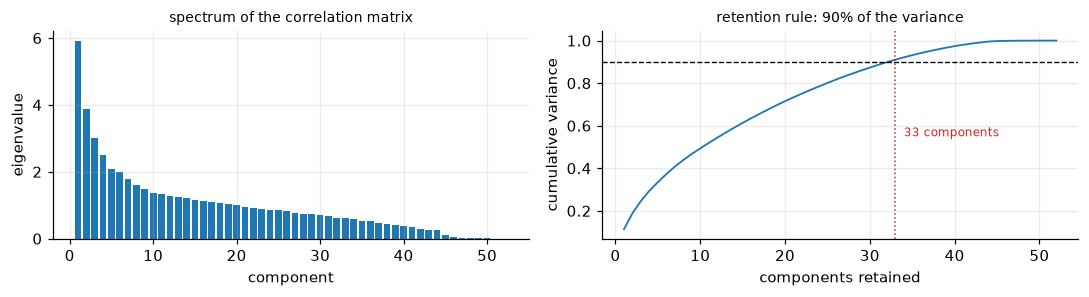

largest eigenvalue is 5.910, 11.4% of the total of 52.0


In [8]:
values = model["values"]
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
axes[0].bar(np.arange(1, len(values) + 1), values, width=0.8, color="tab:blue")
axes[0].set_xlabel("component")
axes[0].set_ylabel("eigenvalue")
axes[0].set_title("spectrum of the correlation matrix", fontsize=9)
axes[1].plot(np.arange(1, len(values) + 1), np.cumsum(values) / values.sum(), lw=1.2)
axes[1].axhline(0.90, color="k", ls="--", lw=0.9)
axes[1].axvline(model["k"], color="tab:red", ls=":", lw=1.0)
axes[1].annotate("%d components" % model["k"], (model["k"] + 1, 0.55), fontsize=8,
                 color="tab:red")
axes[1].set_xlabel("components retained")
axes[1].set_ylabel("cumulative variance")
axes[1].set_title("retention rule: 90% of the variance", fontsize=9)
fig.tight_layout()
plt.show()

print("largest eigenvalue is %.3f, %.1f%% of the total of %.1f"
      % (values[0], 100 * values[0] / values.sum(), values.sum()))

## False alarms first

A detector's false alarm rate has to be measured on fault-free data the model has never
seen. Measured on the training data it is a property of the fit, not of the detector.

The nominal rate is 1%, because the limits were drawn at 99% confidence. Here is what
actually happens on a fresh 48-hour fault-free run.

In [9]:
clean_run = tep.Simulation(fault_free(48.0, TEST_SEED)).run()
clean_t2, clean_spe = pcamon.statistics(model, observed(clean_run))
clean = {"T-squared": pcamon.report(pcamon.alarms_above(clean_t2, t2_limit), len(clean_t2)),
         "SPE": pcamon.report(pcamon.alarms_above(clean_spe, spe_limit), len(clean_spe))}

print("nominal false alarm rate at %.0f%% confidence: %.3f" % (100 * CONFIDENCE,
                                                               1 - CONFIDENCE))
for name, r in clean.items():
    print("  %-10s %4d alarms in %d samples, FAR %.4f"
          % (name, r["false_alarms"], r["samples"], r["false_alarm_rate"]))

nominal false alarm rate at 99% confidence: 0.010
  T-squared    32 alarms in 960 samples, FAR 0.0333
  SPE         174 alarms in 960 samples, FAR 0.1812


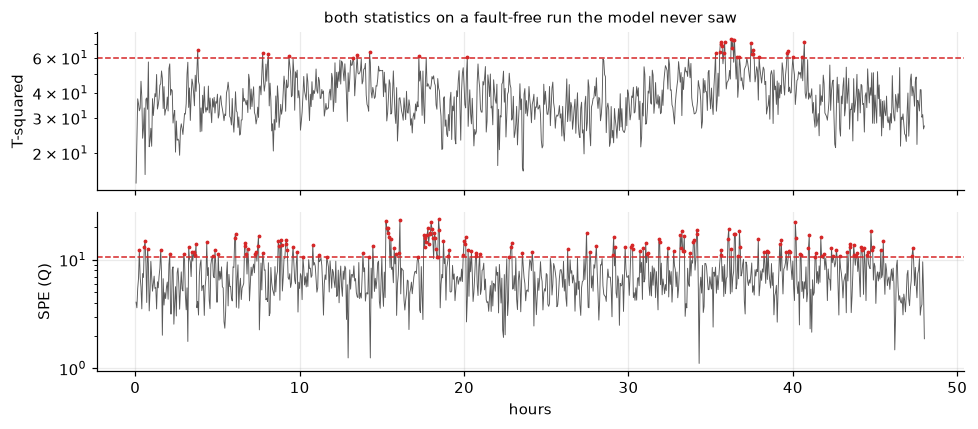

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.0), sharex=True)
for ax, stat, limit, name in [(axes[0], clean_t2, t2_limit, "T-squared"),
                              (axes[1], clean_spe, spe_limit, "SPE (Q)")]:
    ax.semilogy(clean_run.hours, stat, lw=0.6, color="0.35")
    ax.axhline(limit, color="tab:red", ls="--", lw=1.0)
    above = stat > limit
    ax.plot(clean_run.hours[above], stat[above], ".", ms=3, color="tab:red")
    ax.set_ylabel(name)
axes[1].set_xlabel("hours")
axes[0].set_title("both statistics on a fault-free run the model never saw", fontsize=10)
fig.tight_layout()
plt.show()

T-squared holds up reasonably: 3.3% against a nominal 1%. SPE does not, at 18%, a factor
of eighteen. That is not an arithmetic error in `spe_limit`, which computes the
Jackson-Mudholkar expression exactly as stated. It is the assumption underneath the
expression failing.

The limit is derived for residuals that are normal and independent. The Tennessee
Eastman's are neither. Several feed conditions are driven by slow random walks that never
stop, so a 48-hour record wanders somewhere a 25-hour training record did not go, and when
it does, every sample in the excursion alarms together. The plot above shows exactly that
shape: the SPE alarms come in long blocks, not as isolated points.

This is why counts are reported alongside rates. "The detector had a high false alarm
rate" cannot be compared against the next run; 174 alarms in 960 samples can.

## Scoring a fault

Now the same model on a faulted record, with the fault arriving at hour 8. `IDV(4)` is the
one from notebook 1: a 5 C step in the reactor cooling water inlet temperature, which the
controller absorbs into the cooling water valve almost completely.

The two statistics behave completely differently on it, and the reason is instructive. The
controller holds the reactor temperature, so the plant does not move far along the
directions the training data spans, and T-squared is only intermittently outside its
limit. But the *combination* of variables is new: a cooling water valve that far open with
a reactor temperature that normal is a relationship the training data never contained.
That is precisely what the residual subspace is for, and SPE sees it on the first sample.

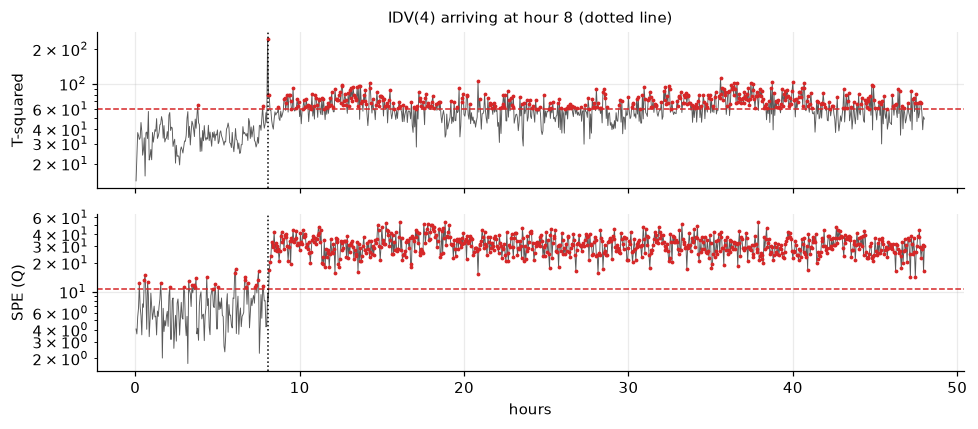

T-squared  FDR 0.541 (433 of 800 post-onset)   FAR 0.013 (2 of 160 pre-onset)   delay 0 samples
SPE        FDR 0.998 (798 of 800 post-onset)   FAR 0.169 (27 of 160 pre-onset)   delay 2 samples


In [11]:
faulted = tep.Simulation(arriving_at(4, 8.0, fault_free(48.0, TEST_SEED))).run()
f_t2, f_spe = pcamon.statistics(model, observed(faulted))

fig, axes = plt.subplots(2, 1, figsize=(9, 4.0), sharex=True)
for ax, stat, limit, name in [(axes[0], f_t2, t2_limit, "T-squared"),
                              (axes[1], f_spe, spe_limit, "SPE (Q)")]:
    ax.semilogy(faulted.hours, stat, lw=0.6, color="0.35")
    ax.axhline(limit, color="tab:red", ls="--", lw=1.0)
    above = stat > limit
    ax.plot(faulted.hours[above], stat[above], ".", ms=3, color="tab:red")
    ax.axvline(faulted.hours[ONSET], color="k", ls=":", lw=1.0)
    ax.set_ylabel(name)
axes[1].set_xlabel("hours")
axes[0].set_title("IDV(4) arriving at hour 8 (dotted line)", fontsize=10)
fig.tight_layout()
plt.show()

for name, stat, limit in [("T-squared", f_t2, t2_limit), ("SPE", f_spe, spe_limit)]:
    r = pcamon.report(pcamon.alarms_above(stat, limit), ONSET, CONSECUTIVE)
    print("%-10s FDR %.3f (%d of %d post-onset)   FAR %.3f (%d of %d pre-onset)   "
          "delay %s samples"
          % (name, r["fault_detection_rate"], r["detections"], r["post_fault"],
             r["false_alarm_rate"], r["false_alarms"], r["pre_fault"],
             r["detection_delay"]))

## The three numbers, and what they mean

The **fault detection rate** is the fraction of post-onset samples that raised an alarm.
It is a rate over samples, not a per-run yes or no. A detector that catches a fault and
then loses it scores badly, which is the intent: a statistic that drops back inside its
limit while the fault is still running is flickering, not detecting. Its complement, the
missed detection rate, is what the tables in the Tennessee Eastman literature report.

The **false alarm rate** is the same fraction over the pre-onset samples, and it is the
number that makes a detection rate meaningful. A detector with a 20% false alarm rate that
achieves a 20% detection rate has detected nothing.

The **detection delay** is the number of samples from the onset to the first run of three
consecutive alarms. The persistence requirement is not decoration. With a run length of
one, the delay is just the first alarm after the onset, and on a detector with any false
alarm rate at all that is mostly luck: at a 3% false alarm rate the first post-onset sample
alarms by chance one time in thirty, and calling that a delay of zero flatters the
detector. The literature uses three and six and does not agree, so the run length travels
with the number.

Here are eight faults through the same pipeline. Multiply a delay by three minutes to get
a time.

In [12]:
SHOW = [1, 2, 4, 5, 11, 3, 9, 15]

sims = {n: tep.Simulation(arriving_at(n, 8.0, fault_free(48.0, TEST_SEED))) for n in SHOW}
with ThreadPoolExecutor() as pool:
    runs = dict(zip(sims, pool.map(tep.Simulation.run, sims.values())))

print("fault  samples  outcome     T2 FDR  T2 delay      Q FDR   Q delay")
rows = {}
for n in SHOW:
    run = runs[n]
    t2, spe = pcamon.statistics(model, observed(run))
    rt = pcamon.report(pcamon.alarms_above(t2, t2_limit), ONSET, CONSECUTIVE)
    rq = pcamon.report(pcamon.alarms_above(spe, spe_limit), ONSET, CONSECUTIVE)
    rows[n] = (rt, rq)
    delay = lambda d: "never" if d is None else str(d)
    print("IDV(%2d) %7d  %-10s %6.3f  %8s   %8.3f  %8s"
          % (n, len(run), run.outcome, rt["fault_detection_rate"],
             delay(rt["detection_delay"]), rq["fault_detection_rate"],
             delay(rq["detection_delay"])))

print()
print("for comparison, on the fault-free run the same limits gave")
print("  T-squared %.3f, SPE %.3f" % (clean["T-squared"]["false_alarm_rate"],
                                      clean["SPE"]["false_alarm_rate"]))

fault  samples  outcome     T2 FDR  T2 delay      Q FDR   Q delay
IDV( 1)     960  completed   0.998         3      0.999         1
IDV( 2)     960  completed   0.988        12      0.990         9
IDV( 4)     960  completed   0.541         0      0.998         2
IDV( 5)     960  completed   0.295         0      0.484         1
IDV(11)     960  completed   0.540         5      0.771         6
IDV( 3)     960  completed   0.036       550      0.182        21
IDV( 9)     960  completed   0.036       550      0.189        22
IDV(15)     960  completed   0.036       550      0.193        22

for comparison, on the fault-free run the same limits gave
  T-squared 0.033, SPE 0.181


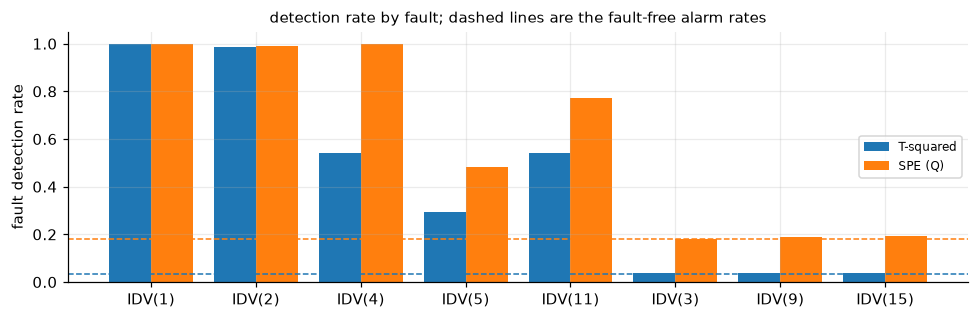

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.0))
x = np.arange(len(SHOW))
ax.bar(x - 0.2, [rows[n][0]["fault_detection_rate"] for n in SHOW], 0.4, label="T-squared")
ax.bar(x + 0.2, [rows[n][1]["fault_detection_rate"] for n in SHOW], 0.4, label="SPE (Q)")
ax.axhline(clean["T-squared"]["false_alarm_rate"], color="tab:blue", ls="--", lw=1.0)
ax.axhline(clean["SPE"]["false_alarm_rate"], color="tab:orange", ls="--", lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(["IDV(%d)" % n for n in SHOW])
ax.set_ylabel("fault detection rate")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="center right")
ax.set_title("detection rate by fault; dashed lines are the fault-free alarm rates",
             fontsize=10)
fig.tight_layout()
plt.show()

The dashed lines are the whole argument. A bar that does not clear its own dashed line is
a detector producing noise, and the last three faults on the chart do not clear it. That
is not an accident of this seed or this model, and it is the subject of notebook 3.

## What is actually wrong with the SPE limit

An 18% false alarm rate against a nominal 1% is unusable, and the tempting response is to
lower the confidence level until it looks right. That is not a fix, it is hiding the
problem in a number nobody will check. It is worth finding out what is broken.

There are two candidate explanations. Either the Jackson-Mudholkar expression is the
wrong approximation for this residual spectrum, or the training record is too short to
have seen the range the plant actually wanders over. They make different predictions, so
the question can be settled by an experiment: hold everything else fixed and lengthen the
training record.

In [14]:
lengths = [25.0, 100.0, 200.0, 500.0]
sims = {h: tep.Simulation(fault_free(h, TRAIN_SEED)) for h in lengths}
with ThreadPoolExecutor() as pool:
    longer = dict(zip(sims, pool.map(tep.Simulation.run, sims.values())))

print("training                      T-squared              SPE (Q)")
print("  hours  samples   k      limit     FAR       limit     FAR")
for h in lengths:
    m = pcamon.fit(observed(longer[h]), retain=0.90)
    tl = pcamon.t_squared_limit(m["k"], m["samples"], CONFIDENCE)
    sl = pcamon.spe_limit(m["values"][m["k"]:], CONFIDENCE)
    a, b = pcamon.statistics(m, observed(clean_run))
    print("  %5.0f   %6d  %2d   %8.3f  %.4f    %8.3f  %.4f"
          % (h, m["samples"], m["k"], tl, pcamon.alarms_above(a, tl).mean(),
             sl, pcamon.alarms_above(b, sl).mean()))
print()
print("nominal false alarm rate: %.4f" % (1 - CONFIDENCE))

training                      T-squared              SPE (Q)
  hours  samples   k      limit     FAR       limit     FAR
     25      500  33     60.141  0.0333      10.593  0.1812
    100     2000  32     54.680  0.0063      10.989  0.0219
    200     4000  32     54.077  0.0083      11.437  0.0177
    500    10000  33     55.022  0.0104      10.495  0.0115

nominal false alarm rate: 0.0100


That settles it. With 500 hours of fault-free training data both statistics land on the
nominal 1%, the SPE limit included. The Jackson-Mudholkar expression was never the
problem. A 25-hour record simply does not contain the tails of a process whose feed
conditions are driven by random walks that never stop, so the residual spread it measures
is too small and the limit it produces is too tight.

This has a direct consequence for the literature, and it is not a comfortable one. The
published training file `d00` holds 500 samples, which at a three-minute interval is 25
hours: exactly the first row of that table. Every SPE false alarm rate reported for static
PCA on the published Tennessee Eastman data inherits this.

Estimating the limit empirically from the training residuals instead of analytically is
the usual advice, and it is worth checking rather than assuming:

In [15]:
train_t2, train_spe = pcamon.statistics(model, observed(training))
empirical_t2 = float(np.quantile(train_t2, CONFIDENCE))
empirical_spe = float(np.quantile(train_spe, CONFIDENCE))

print("limits at the %.0f%% level from the 25-hour training record" % (100 * CONFIDENCE))
print("                              limit   fault-free FAR")
for name, limit, stat in [("T-squared, F distribution", t2_limit, clean_t2),
                          ("T-squared, empirical     ", empirical_t2, clean_t2),
                          ("SPE, Jackson-Mudholkar   ", spe_limit, clean_spe),
                          ("SPE, empirical           ", empirical_spe, clean_spe)]:
    print("  %s   %8.3f   %.4f"
          % (name, limit, pcamon.alarms_above(stat, limit).mean()))

limits at the 99% level from the 25-hour training record
                              limit   fault-free FAR
  T-squared, F distribution     60.141   0.0333
  T-squared, empirical          52.112   0.1042
  SPE, Jackson-Mudholkar        10.593   0.1812
  SPE, empirical                11.323   0.1448


It does not help. The empirical SPE limit is a small improvement and the empirical
T-squared limit is markedly worse than the analytic one, because both are drawn from the
same 25 hours that were too short in the first place and neither can know about the
excursions it never saw.

The fix is more data, or a method that models the serial correlation rather than assuming
it away. Dynamic PCA, which augments each observation with lagged copies of itself, and
canonical variate analysis are the two the Tennessee Eastman literature reaches for, and
Russell, Chiang and Braatz (2000) is specifically a comparison of those two against static
PCA on this plant. This repository's `tepsim-stats` crate has `dpca` and `cva`
implementations if you want to go further.

The rest of these notebooks keep the analytic limits on a short training record, because
that is what the published results were computed with, and comparing against them is the
point of notebook 3.

## References

- E. L. Russell, L. H. Chiang and R. D. Braatz, "Fault detection in industrial processes
  using canonical variate analysis and dynamic principal component analysis",
  *Chemometrics and Intelligent Laboratory Systems* **51**(1), 81-93 (2000).
  doi:10.1016/S0169-7439(00)00058-7
- L. H. Chiang, E. L. Russell and R. D. Braatz, *Fault Detection and Diagnosis in
  Industrial Systems*, Springer London (2001). doi:10.1007/978-1-4471-0347-9
- J. J. Downs and E. F. Vogel, "A plant-wide industrial process control problem",
  *Computers & Chemical Engineering* **17**(3), 245-255 (1993).
  doi:10.1016/0098-1354(93)80018-I